# Notebook 05 — Time

## Overview

Every event happens *at a time*. A pizza order arrives, baking begins, baking ends, and the pizza is delivered — each of these happenings occupies a position on the timeline. Ontologies that represent processes (as we did in notebook 03) are incomplete without some account of *when* those processes occur.

SULO provides a minimal but sufficient vocabulary for temporal representation:

| Class | Description |
|---|---|
| `sulo:TimeInstant` | A specific point on the timeline |
| `sulo:StartTime` | A `TimeInstant` marking the beginning of a process |
| `sulo:EndTime` | A `TimeInstant` marking the end of a process |
| `sulo:Duration` | A measured amount of elapsed time |

`sulo:atTime` links a process (or any entity) to a `Time` individual. `sulo:precedes` (introduced in notebook 03) provides a transitive ordering between processes; together with `atTime`, it gives us both a sequential order over processes and a way to anchor each process to specific time instants.

Beyond recording *when* things happen, `atTime` also enables **classification of processes**: a delivery process linked to a `DeliveryDuration` with `hasValue ≤ 30` can be automatically classified as `ExpressPizzaDelivery` by the reasoner.

## Learning Objectives

1. Understand SULO's time vocabulary (`TimeInstant`, `StartTime`, `EndTime`, `Duration`) and the `atTime` property
2. Define named `TimeInstant` subclasses, choosing `StartTime` or `EndTime` as parent where the instant marks a process boundary
3. Constrain `Duration` subclasses using `hasValue` with `ConstrainedDatatype`, parallel to the quantity pattern from notebook 02
4. Attach time-instant classes to process classes at the TBox level using `atTime some`
5. Build an instance-level temporal chain: chain process individuals with `sulo:precedes`, attach time instants via `sulo:atTime`, and verify process transitivity via `INDIRECT_precedes`
6. Define a process subclass using a combined `atTime` and `ConstrainedDatatype` restriction, and verify that individual processes are classified automatically by the reasoner

## Getting started

The following cell loads SULO, the `pro` ontology, and the pizza ontology built in notebook 04.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()
pro = get_ontology("dist/pro.owl").load()
pizza = get_ontology("dist/pizza-04.owl").load()
pizza.imported_ontologies.append(sulo)
pizza.imported_ontologies.append(pro)


result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

print("Loaded pizza ontology. Classes:", len(list(pizza.classes())))

Consistent: True
Loaded pizza ontology. Classes: 51


## New Process Classes

Two process classes complete the pizza lifecycle pipeline: `OrderingProcess` marks the arrival of a customer order, and `DeliveringThePizza` marks its final leg. Both are primitive subclasses of `sulo:Process` — neither consumes inputs to produce outputs (which would be a transformation), nor does ordering or delivery involve developmental change.

Once defined, we extend the TBox-level `precedes` chain from notebook 03:

| Axiom | Meaning |
|---|---|
| `OrderingProcess precedes some MakingThePizzaDough` | ordering precedes dough-making |
| `SlicingThePizza precedes some DeliveringThePizza` | slicing precedes delivery |

In [2]:
with pizza:
    class OrderingProcess(sulo.Process):
        """The process of placing a pizza order — the first step in the pizza lifecycle,
        preceding all production processes."""
        label = [locstr("ordering process", "en")]

    class DeliveringThePizza(sulo.Process):
        """The process of transporting the finished pizza to the customer."""
        label = [locstr("delivering the pizza", "en")]

    # Extend the TBox precedes chain from notebook 03
    OrderingProcess.is_a.append(sulo.precedes.some(pizza.MakingThePizzaDough))
    pizza.SlicingThePizza.is_a.append(sulo.precedes.some(DeliveringThePizza))

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("OrderingProcess is_a:", OrderingProcess.is_a)
print("SlicingThePizza precedes:", [a for a in pizza.SlicingThePizza.is_a if hasattr(a, 'property') and a.property == sulo.precedes])

Consistent: True
OrderingProcess is_a: [sulo.Process, sulo.precedes.some(pizza-04.MakingThePizzaDough)]
SlicingThePizza precedes: [sulo.precedes.some(pizza-04.DeliveringThePizza)]


## Time Instant Subclasses

`sulo:StartTime` and `sulo:EndTime` are subclasses of `TimeInstant` that mark the temporal boundaries of a process. A time instant that does not serve as a process boundary is simply a `sulo:TimeInstant`.

| Class | Parent | Marks |
|---|---|---|
| `OrderReceivedTime` | `sulo:TimeInstant` | When a pizza order arrives (not a process boundary) |
| `MakingStartTime` | `sulo:StartTime` | When dough-making begins |
| `MakingEndTime` | `sulo:EndTime` | When dough-making ends |
| `BakingStartTime` | `sulo:StartTime` | When baking begins |
| `BakingEndTime` | `sulo:EndTime` | When baking ends |
| `DeliveryTime` | `sulo:TimeInstant` | When the pizza is delivered (not a process boundary) |

In [3]:
with pizza:
    class OrderReceivedTime(sulo.TimeInstant):
        """The point in time at which a pizza order was received."""
        label = [locstr("order received time", "en")]

    class MakingStartTime(sulo.StartTime):
        """The point in time at which dough-making began."""
        label = [locstr("making start time", "en")]

    class MakingEndTime(sulo.EndTime):
        """The point in time at which dough-making ended."""
        label = [locstr("making end time", "en")]

    class BakingStartTime(sulo.StartTime):
        """The point in time at which pizza baking began."""
        label = [locstr("baking start time", "en")]

    class BakingEndTime(sulo.EndTime):
        """The point in time at which pizza baking ended."""
        label = [locstr("baking end time", "en")]

    class DeliveryTime(sulo.TimeInstant):
        """The point in time at which the pizza was delivered."""
        label = [locstr("delivery time", "en")]

print("MakingStartTime ancestors:", [a.name for a in MakingStartTime.ancestors() if hasattr(a,'name')])
print("OrderReceivedTime ancestors:", [a.name for a in OrderReceivedTime.ancestors() if hasattr(a,'name')])

MakingStartTime ancestors: ['StartTime', 'Object', 'Thing', 'Time', 'MakingStartTime', 'InformationObject', 'TimeInstant', 'Feature', 'Quantity']
OrderReceivedTime ancestors: ['Object', 'Thing', 'Time', 'InformationObject', 'TimeInstant', 'OrderReceivedTime', 'Feature', 'Quantity']


`sulo:atTime` is the property that links a process individual to a time-instant individual. `sulo:isTimeOf` is its inverse. At the TBox level we use `atTime some BakingStartTime` to say every baking event must have an associated `BakingStartTime`; at the ABox level we assert `baking_001.atTime = [t_bake_start]` for a concrete event.

## Duration with Constraints

A `Duration` is a `Quantity` that measures elapsed time. Like `SpicynessMeasurement` in notebook 02, we can constrain the value of a duration to define specific kinds: `BakingDuration` is defined with a normal baking window of 8–15 minutes.

`DeliveryDuration` is left as a primitive subclass with no intrinsic constraint — delivery time has no fixed upper bound in general. The constraint appears later in `ExpressPizzaDelivery`, where a delivery carrying a duration ≤ 30 minutes is classified as express. Separating the constraint from the duration class lets the same `DeliveryDuration` be used for both express and non-express deliveries.

`hasValue` stores ISO 8601 timestamp strings for time-instant individuals (e.g. `"2026-04-30T17:00:00Z"`) and floats for duration individuals (e.g. `25.0` minutes). Both use the same `hasValue` property — the XSD datatype is inferred from the Python value passed.

In [4]:
with pizza:
    class DeliveryDuration(sulo.Duration):
        """The elapsed time from order placement to pizza delivery, measured in minutes."""
        label = [locstr("delivery duration", "en")]

    class BakingDuration(sulo.Duration):
        """The elapsed time for baking a pizza, measured in minutes."""
        label = [locstr("baking duration", "en")]
        equivalent_to = [
            sulo.Duration
            & sulo.hasValue.some(ConstrainedDatatype(float, min_inclusive=8, max_inclusive=15))
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

Consistent: True


## Attaching Time to Processes

SULO's `atTime` property links any entity to a `Time` individual. We use it to say that a *class* of process is associated with a *class* of time instant — every instance of `BakingThePizza` is associated with some `BakingStartTime`.

This is a TBox (class-level) assertion: it constrains how instances must be described.

In [5]:
# Retrieve process classes defined in notebook 03
BakingThePizza      = pizza.BakingThePizza
SlicingThePizza     = pizza.SlicingThePizza
MakingThePizzaDough = pizza.MakingThePizzaDough

with pizza:
    MakingThePizzaDough.is_a.append(sulo.atTime.some(MakingStartTime))
    MakingThePizzaDough.is_a.append(sulo.atTime.some(MakingEndTime))
    BakingThePizza.is_a.append(sulo.atTime.some(BakingStartTime))
    BakingThePizza.is_a.append(sulo.atTime.some(BakingEndTime))

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

print("MakingThePizzaDough axioms:")
for a in MakingThePizzaDough.is_a:
    print(" ", a)
print("BakingThePizza axioms:")
for a in BakingThePizza.is_a:
    print(" ", a)

Consistent: True
MakingThePizzaDough axioms:
  pro.TransformationProcess
  pro.TransformationProcess & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-04.Flour)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-04.Water)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-04.Sugar)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-04.BakersYeast)) & sulo.hasParticipant.some(pro.ConsumedRole & sulo.isFeatureOf.some(pizza-04.Salt)) & sulo.hasParticipant.some(pro.EmergingRole & sulo.isFeatureOf.some(pizza-04.PizzaDough)) & sulo.hasParticipant.some(pizza-04.BakerRole & sulo.isFeatureOf.some(pizza-04.Person))
  sulo.precedes.some(pizza-04.ProofingTheDough)
  sulo.atTime.some(pizza-04.MakingStartTime)
  sulo.atTime.some(pizza-04.MakingEndTime)
BakingThePizza axioms:
  pro.DevelopmentalProcess
  sulo.hasPart.some(pizza-04.DoughBaking)
  sulo.hasPart.some(pizza-04.CheeseMelting)
  sulo.precedes.som

## A Complete Pizza Timeline

At the **instance level**, we represent a specific pizza order as a set of individuals with concrete temporal relations. Process individuals are chained with `sulo:precedes`; time-instant individuals are attached to their respective processes via `sulo:atTime`. Together, these let us answer questions such as "in what order did these processes occur?" or "was this delivery express?"

In [6]:
with pizza:
    # ── Process individuals ────────────────────────────────────────────────
    ordering_001   = OrderingProcess("ordering_event_001")
    making_001     = pizza.MakingThePizzaDough("making_event_001")
    baking_001     = BakingThePizza("baking_event_001")
    delivering_001 = DeliveringThePizza("delivering_event_001")

    # Process sequence — sulo:precedes is transitive
    ordering_001.precedes = [making_001]
    making_001.precedes   = [baking_001]
    baking_001.precedes   = [delivering_001]

    # ── Time instants attached to processes via atTime ────────────────────
    t_order_received = OrderReceivedTime("t_order_received_001")
    t_order_received.label    = ["Order received — order #001"]
    t_order_received.hasValue = "2026-04-30T17:00:00Z"
    ordering_001.atTime = [t_order_received]

    t_making_start = MakingStartTime("t_making_start_001")
    t_making_start.label    = ["Dough-making start — order #001"]
    t_making_start.hasValue = "2026-04-30T17:01:00Z"

    t_making_end = MakingEndTime("t_making_end_001")
    t_making_end.label    = ["Dough-making end — order #001"]
    t_making_end.hasValue = "2026-04-30T17:46:00Z"

    making_001.atTime = [t_making_start, t_making_end]

    t_bake_start = BakingStartTime("t_bake_start_001")
    t_bake_start.label    = ["Baking start — order #001"]
    t_bake_start.hasValue = "2026-04-30T17:46:00Z"

    t_bake_end = BakingEndTime("t_bake_end_001")
    t_bake_end.label    = ["Baking end — order #001"]
    t_bake_end.hasValue = "2026-04-30T17:58:00Z"

    baking_001.atTime = [t_bake_start, t_bake_end]

    t_delivery = DeliveryTime("t_delivery_001")
    t_delivery.label    = ["Delivery time — order #001"]
    t_delivery.hasValue = "2026-04-30T18:23:00Z"

    dur_001 = DeliveryDuration("delivery_duration_001")
    dur_001.hasValue = 25.0
    delivering_001.atTime = [t_delivery, dur_001]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])
print("Delivery duration:", dur_001.hasValue, "minutes")

Consistent: True
Delivery duration: 25.0 minutes


In [7]:
# sulo:precedes is transitive — ordering_001 directly precedes only making_001,
# but INDIRECT_precedes follows the chain all the way to delivering_001
print("direct  :", [x.name for x in ordering_001.precedes])
print("indirect:", [x.name for x in ordering_001.INDIRECT_precedes])

direct  : ['making_event_001']
indirect: ['MakingThePizzaDough', 'making_event_001']


## Classifying a Delivery as Express

`ExpressPizzaDelivery` is a defined class: a `DeliveringThePizza` process that has `atTime` some `DeliveryDuration` whose `hasValue` is at most 30. Because the condition is on the *process* (linked via `atTime` to a qualifying duration), the reasoner classifies any delivery process individual carrying such a duration as express — without any explicit type assertion.

In [8]:
with pizza:
    class ExpressPizzaDelivery(DeliveringThePizza):
        """A pizza delivery process completed in at most 30 minutes."""
        label = [locstr("express pizza delivery", "en")]
        equivalent_to = [
            DeliveringThePizza
            & sulo.atTime.some(
                DeliveryDuration
                & sulo.hasValue.some(ConstrainedDatatype(float, max_inclusive=30)))
        ]

result = safe_call_reasoner(pizza)
print("Consistent:", result["ok"])

inferred = [t for t in delivering_001.is_a if hasattr(t, 'name')]
print("delivering_001 inferred types:", inferred)

if ExpressPizzaDelivery in delivering_001.is_a:
    print(f"\ndelivering_001 ({dur_001.hasValue} min) IS classified as ExpressPizzaDelivery ✓")
else:
    print(f"\ndelivering_001 ({dur_001.hasValue} min) is NOT classified as ExpressPizzaDelivery")

Consistent: True
delivering_001 inferred types: [pizza-04.ExpressPizzaDelivery]

delivering_001 (25.0 min) IS classified as ExpressPizzaDelivery ✓


Saved pizza-05.owl


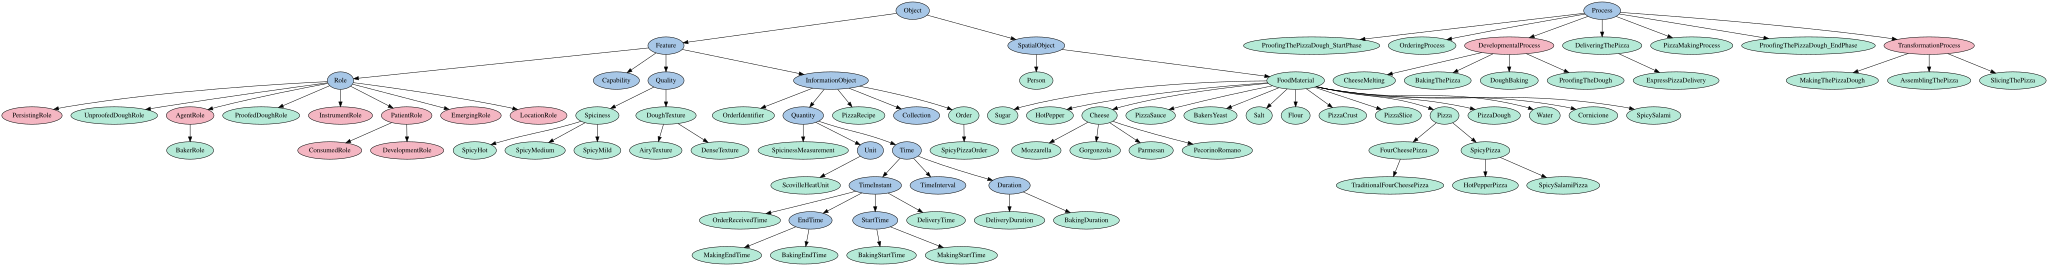

In [9]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-05.owl", format="rdfxml")
print("Saved pizza-05.owl")
display(get_color_tree([sulo, pro, pizza]))

---

### YOUR TURN 1 — `ProofingDuration`

Define a `ProofingDuration` subclass of `sulo:Duration` representing the time the dough is left to ferment. A minimum proofing time of 60 minutes produces better flavour. Define `SlowFermentedDough` as a `PizzaDough` that `hasFeature` some `ProofingDuration` with `hasValue >= 60`. Run the reasoner and verify consistency.

In [10]:
# Exercise 1 — your code here


### YOUR TURN 2 — `PizzaOrderFulfillment`

Define `PizzaOrderFulfillment` as a defined class: a `sulo:Process` that `hasPart` some `OrderingProcess` and `hasPart` some `DeliveringThePizza`. Then create a plain `sulo:Process` individual, attach an `OrderingProcess` individual and a `DeliveringThePizza` individual as parts, run the reasoner, and verify that the individual is automatically classified as `PizzaOrderFulfillment`.

In [11]:
# YOUR TURN 2 — your code here

---

## Summary

In this notebook we added a temporal dimension to the pizza ontology, defining time-instant and duration classes tied to the process pipeline from notebook 03, and building a complete instance-level timeline.

### What we built

**Process extensions**

| Class | Parent | Role in the pipeline |
|---|---|---|
| `OrderingProcess` | `sulo:Process` | first step; precedes `MakingThePizzaDough` |
| `DeliveringThePizza` | `sulo:Process` | last step; follows `SlicingThePizza` |
| `ExpressPizzaDelivery` | `DeliveringThePizza` | delivery with `atTime some (DeliveryDuration & hasValue ≤ 30)` |

**Time instant classes**

| Class | Parent | Marks |
|---|---|---|
| `OrderReceivedTime` | `sulo:TimeInstant` | start of `OrderingProcess` |
| `MakingStartTime` | `sulo:StartTime` | start of `MakingThePizzaDough` |
| `MakingEndTime` | `sulo:EndTime` | end of `MakingThePizzaDough` |
| `BakingStartTime` | `sulo:StartTime` | start of `BakingThePizza` |
| `BakingEndTime` | `sulo:EndTime` | end of `BakingThePizza` |
| `DeliveryTime` | `sulo:TimeInstant` | `DeliveringThePizza` |

**Duration classes**

| Class | Constraint | Meaning |
|---|---|---|
| `DeliveryDuration` | — | elapsed delivery time in minutes |
| `BakingDuration` | `8 ≤ hasValue ≤ 15` | normal baking window |

### Key concepts

**`StartTime` and `EndTime` as process boundaries.** `sulo:StartTime` and `sulo:EndTime` are subclasses of `TimeInstant` that mark the temporal boundaries of a process. A time instant that does not serve as a process boundary — such as when an order was received or when a delivery arrived — is simply a `sulo:TimeInstant`.

**Process ordering and time anchoring.** `sulo:precedes` provides a transitive ordering between process individuals. `sulo:atTime` anchors each process to one or more time instants. `INDIRECT_precedes` follows the transitive chain across all downstream processes.

**TBox vs ABox temporal assertions.** `BakingThePizza.is_a.append(atTime.some(BakingStartTime))` is a class-level constraint applying to all baking instances. `baking_001.atTime = [t_bake_start]` is an individual assertion for one specific event.

**Classifying processes via `atTime`.** `ExpressPizzaDelivery` is defined as a `DeliveringThePizza` with `atTime some (DeliveryDuration & hasValue ≤ 30)`. The reasoner classifies any delivery process carrying such a duration as express.

### What comes next

Notebook 06 covers **spatial containment** — representing where pizzas are located using `sulo:contains` and `sulo:isIn`, and how containment interacts with parthood.